# Model Validation on Full Dataset

In the main project, a version of the dataset (4,521 records) was used for model development. This version was first verified against the full dataset to ensure it preserves the same patterns and distributions. It was then used to run experiments more efficiently in terms of time and computational cost, especially when comparing multiple models and imbalance handling techniques.

Based on these experiments, **XGBoost with SMOTEENN** was selected as the best-performing model.

This notebook represents the final validation stage of the project. The selected model is applied to the full Bank Marketing dataset (45,211 records) to confirm that its performance remains stable beyond the version used during experimentation.

A brief data check and exploratory analysis are included to verify consistency, followed by training and evaluating the model using the same preprocessing and pipeline setup.

The goal is to assess whether the model maintains consistent performance and generalizes well when applied to the full dataset.

## Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
%matplotlib inline

In [3]:
# Load data using project root path

PROJECT_ROOT = Path().resolve().parent.parent
data_path = PROJECT_ROOT / "bank-deposit-prediction" / "data" / "raw" / "bank-full.csv"

df = pd.read_csv(data_path, sep=";")

# Preview
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Dataset Overview

In [4]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Column names, Data types and non-null counts
df.info()

Shape of dataset: (45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


## Missing Values 

In [5]:
missing_values = df.isnull().sum()

print("Missing values per column:\n")
print(missing_values[missing_values > 0])

Missing values per column:

Series([], dtype: int64)


In [6]:
# Checking 'unknown' values in categorical features

categorical_cols = df.select_dtypes(include='object').columns

print("Columns with 'unknown' values:")

for col in categorical_cols:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        percentage = (count / len(df)) * 100
        print(f"{col}: {count} ({percentage:.2f}%)")

Columns with 'unknown' values:
job: 288 (0.64%)
education: 1857 (4.11%)
contact: 13020 (28.80%)
poutcome: 36959 (81.75%)


## Duplicate Records

In [7]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


## Outlier Analysis

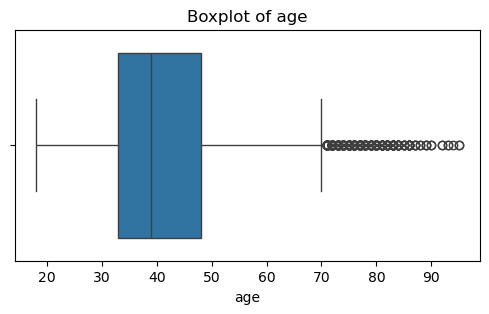

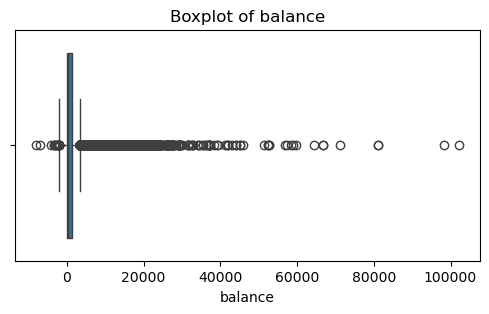

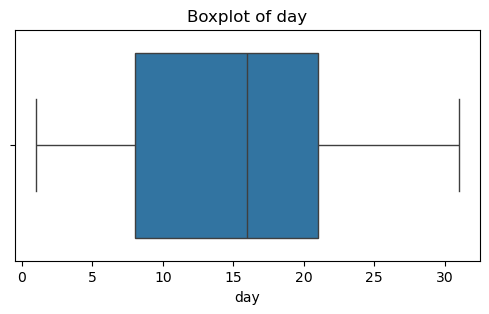

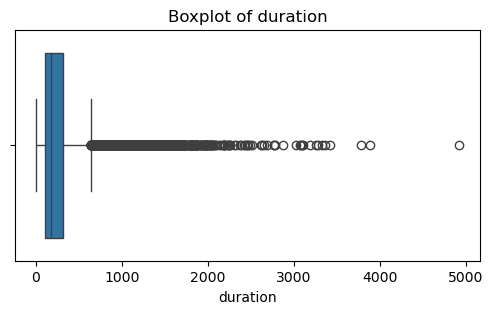

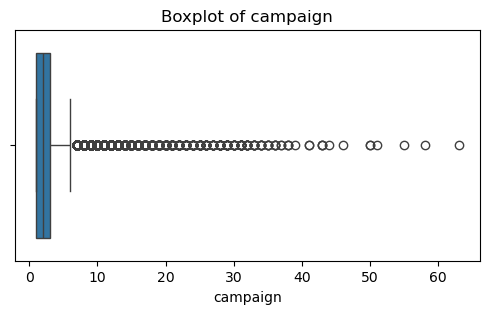

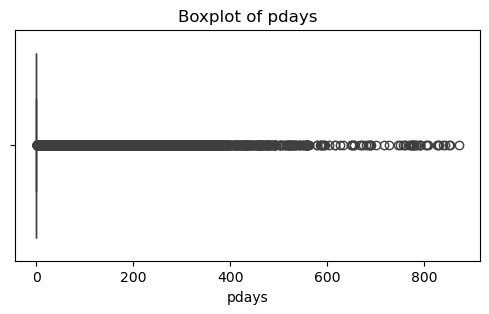

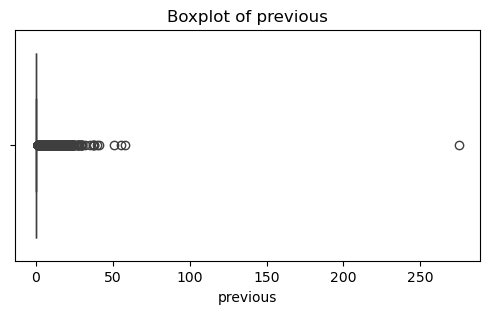

In [8]:
numerical_cols = df.select_dtypes(include=['int64']).columns

# Use boxplots to inspect potential outliers in numerical features
for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Target Variable Analysis

y
no     39922
yes     5289
Name: count, dtype: int64

Percentage:
 y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


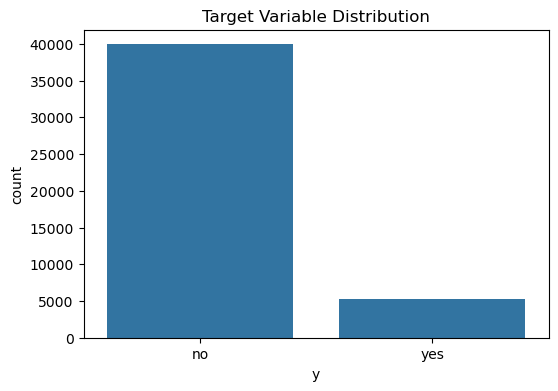

In [9]:
# Count
target_counts = df['y'].value_counts()
print(target_counts)

# Percentage
target_ratio = df['y'].value_counts(normalize=True)
print("\nPercentage:\n", target_ratio)

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

## Numerical Features Analysis

In [10]:

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:\n", numerical_cols)

# Summary statistics
df[numerical_cols].describe()

Numerical Columns:
 Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Categorical Features Analysis

In [11]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols = categorical_cols.drop('y')  # exclude target

print("Categorical Columns:\n", categorical_cols)

Categorical Columns:
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')


## Findings & Preprocessing Strategy 


### Findings:

* The full dataset follows the same structure and general feature characteristics as the version used in the experimental phase.

* No explicit missing values or duplicate records were found, which is consistent with the earlier observations.

* The feature `poutcome` still contains a high percentage of "unknown" values (around **81.75%**). As before, these are treated as a valid category rather than missing data, since they provide useful information about past campaign interactions.

* The target variable remains imbalanced, with approximately:

  
     - **88.3% "no"**
     - **11.7% "yes"**

This confirms that the imbalance is an inherent property of the dataset and not a result of sampling, so the same handling strategy is required.

* Outlier patterns are also consistent. Features such as `balance`, `campaign`, and `pdays` continue to show skewness and extreme values. These are retained, and **Robust Scaling** is applied to reduce their impact.

* In line with the version of the dataset used during the experimental phase, the `duration` feature is identified as a source of data leakage, since it is only known after the call.  

* Similarly, the `default` feature remains highly imbalanced with very low variance.

* These features are handled in the same way as in the earlier experiments through the shared preprocessing pipeline.

* The `day` feature is also handled consistently, being treated as a categorical variable since it represents a time-based concept rather than a continuous one.

### Preprocessing:

Since the full dataset exhibits the same patterns as the version used, the preprocessing pipeline remains unchanged. The same steps are applied to ensure consistency between experimentation and final validation.

The data is therefore ready for validating the selected model (**XGBoost with SMOTEENN**) on the full dataset.


## Final Model Validation (XGBoost + SMOTEENN)


## Setup

In [12]:

# Add project root to system path so we can import from src/
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent / "bank-deposit-prediction"
sys.path.append(str(PROJECT_ROOT))


from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Imbalanced learning tools
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN

# Shared project modules
from src.shared import get_cv, get_preprocessing_steps, Pipeline
from src.evaluation import evaluate_model

In [13]:

y = df['y'].map({'yes': 1, 'no': 0})
X = df.drop(columns=['y'])

## Shared components
The following components are used throughout the experiments:
- A centralized preprocessing pipeline to prevent data leakage
- Stratified K-Fold cross-validation, ensuring a fair evaluation

In [14]:
# Get shared cross-validation strategy
cv = get_cv()

## Model Testing

In [15]:

xgb_smoteenn_pipeline = ImbPipeline(
    get_preprocessing_steps() +
    [('smoteenn', SMOTEENN(random_state=42)),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

# 2. Run the full-scale evaluation
print("Training and validating XGBoost + SMOTEENN on the full dataset...")
result_smoteenn = evaluate_model("XGBoost", "SMOTEENN", xgb_smoteenn_pipeline, X, y, cv)

# 3. Create the DataFrame directly from the result dictionary
results_df = pd.DataFrame([result_smoteenn])

# 4. Display the table 
results_df


Training and validating XGBoost + SMOTEENN on the full dataset...


,Model,Strategy,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC
0,XGBoost,SMOTEENN,0.8699 ± 0.0025,0.4492 ± 0.0105,0.4976 ± 0.0274,0.4720 ± 0.0175,0.4219 ± 0.0224,0.7926 ± 0.0096
